In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [10]:
# 1) 下載資料
df = yf.download("2330.TW", start="2020-01-01", end="2024-12-31")

df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()

# RSI 計算
delta = df['Close'].diff()
gain = np.maximum(delta, 0)
loss = np.maximum(-delta, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# MACD 計算
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD'] = ema12 - ema26
df['MACD_SIGNAL'] = df['MACD'].ewm(span=9).mean()
df['MACD_HIST'] = df['MACD'] - df['MACD_SIGNAL']

C:\Users\User\AppData\Local\Temp\ipykernel_17536\136827891.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("2330.TW", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


In [11]:
df['logret'] = np.log(df['Close'].shift(-1)) - np.log(df['Close'])
df.dropna(inplace=True)

In [12]:
# 先保留原始 Close（未標準化）用來還原價格
close = df['Close'].copy()

# 2) 特徵與目標
features = df.drop(columns=['logret'])
target = df[['logret']]  # 雙中括號保持 DataFrame 格式

# 3) 資料切分 (8/1/1)
split_train = int(len(df) * 0.8)
split_val = int(len(df) * 0.9)

train_X, val_X, test_X = features.iloc[:split_train], features.iloc[split_train:split_val], features.iloc[split_val:]
train_y, val_y, test_y = target.iloc[:split_train], target.iloc[split_train:split_val], target.iloc[split_val:]

# ⬅️ 這裡額外切分 Close（未標準化）方便還原
train_close = close.iloc[:split_train]
val_close = close.iloc[split_train:split_val]
test_close = close.iloc[split_val:]

# 4) 特徵 scaler
scaler_X = StandardScaler().fit(train_X)
train_X = scaler_X.transform(train_X)
val_X = scaler_X.transform(val_X)
test_X = scaler_X.transform(test_X)

# 5) 目標 scaler（logret）
scaler_y = StandardScaler().fit(train_y)
train_y = scaler_y.transform(train_y)
val_y = scaler_y.transform(val_y)
test_y = scaler_y.transform(test_y)


In [13]:
# 時間序列 Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, lookback=30):
        self.X = X
        self.y = y
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx:idx + self.lookback], dtype=torch.float32),
            torch.tensor(self.y[idx + self.lookback], dtype=torch.float32).squeeze()
        )



lookback = 30
train_ds = TimeSeriesDataset(train_X, train_y, lookback)
val_ds = TimeSeriesDataset(val_X, val_y, lookback)
test_ds = TimeSeriesDataset(test_X, test_y, lookback)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=False)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False)

In [14]:
# 3) 模型定義
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 128, batch_first=True)
        self.norm = nn.LayerNorm(128)
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.norm(out[:, -1, :])
        return self.fc(out)

In [15]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)
    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

class CustomEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.activation = nn.ReLU()

    def forward(self, src):
        # Multi-Head Attention
        attn_output, attn_weights = self.self_attn(src, src, src, need_weights=True)
        src = self.norm1(src + attn_output)  # 殘差 + LayerNorm

        # Feed-forward network
        ff_output = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = self.norm2(src + ff_output)    # 殘差 + LayerNorm

        return src, attn_weights

class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model=64):
        super().__init__()
        self.fc_in = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.encoder_layers = nn.ModuleList([CustomEncoderLayer(d_model, nhead=4) for _ in range(2)])
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x, return_attn=False):
        x = self.fc_in(x)
        x = self.pos_enc(x)

        attn_last = None
        for i, layer in enumerate(self.encoder_layers):
            x, attn_weights = layer(x)
            if i == len(self.encoder_layers) - 1:
                attn_last = attn_weights

        x = x.mean(dim=1)   # Mean pooling
        out = self.fc_out(x)

        if return_attn:
            return out, attn_last
        return out


In [16]:
import torch
import torch.nn as nn
import numpy as np
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingWarmRestarts

def train_model(model, train_dl, val_dl, epochs=30, lr=1e-4, use_warmup=False, warmup_ratio=0.1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Optimizer
    if use_warmup:
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        total_steps = epochs * len(train_dl)
        warmup_steps = int(total_steps * warmup_ratio)

        # Warmup scheduler
        def warmup_lambda(step):
            if step < warmup_steps:
                return float(step) / float(max(1, warmup_steps))
            return 1.0
        warmup_sched = LambdaLR(opt, lr_lambda=warmup_lambda)

        # CosineAnnealingWarmRestarts
        cosine_sched = CosineAnnealingWarmRestarts(opt, T_0=max(1, total_steps - warmup_steps))
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        warmup_sched = None
        cosine_sched = None

    loss_fn = nn.MSELoss()
    global_step = 0

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_dl:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            opt.zero_grad()
            pred = model(X_batch)
            loss = loss_fn(pred.squeeze(), y_batch)
            loss.backward()
            opt.step()

            if use_warmup:
                if global_step < warmup_steps:
                    warmup_sched.step()
                else:
                    cosine_sched.step(epoch + global_step / len(train_dl))
            global_step += 1

        # 驗證
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_dl:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                val_losses.append(loss_fn(pred.squeeze(), y_batch).item())

        print(f"Epoch {epoch+1}, Val RMSE: {np.sqrt(np.mean(val_losses)):.6f}")


In [17]:
# 5) 執行
print('----------- LSTM -----------')
lstm_model = LSTMModel(train_X.shape[1])
train_model(lstm_model, train_dl, val_dl, epochs=30, lr=1e-4)

print('----------- Transformer -----------')
transformer_model = TransformerModel(train_X.shape[1], d_model=64)
train_model(transformer_model, train_dl, val_dl, epochs=30, lr=3e-4, use_warmup=True)

----------- LSTM -----------
Epoch 1, Val RMSE: 1.209240
Epoch 2, Val RMSE: 1.117650
Epoch 3, Val RMSE: 1.118114
Epoch 4, Val RMSE: 1.118049
Epoch 5, Val RMSE: 1.121401
Epoch 6, Val RMSE: 1.126847
Epoch 7, Val RMSE: 1.131752
Epoch 8, Val RMSE: 1.136555
Epoch 9, Val RMSE: 1.140819
Epoch 10, Val RMSE: 1.144284
Epoch 11, Val RMSE: 1.147509
Epoch 12, Val RMSE: 1.150607
Epoch 13, Val RMSE: 1.153539
Epoch 14, Val RMSE: 1.156403
Epoch 15, Val RMSE: 1.159241
Epoch 16, Val RMSE: 1.162058
Epoch 17, Val RMSE: 1.164857
Epoch 18, Val RMSE: 1.167637
Epoch 19, Val RMSE: 1.170391
Epoch 20, Val RMSE: 1.173114
Epoch 21, Val RMSE: 1.175802
Epoch 22, Val RMSE: 1.178450
Epoch 23, Val RMSE: 1.181055
Epoch 24, Val RMSE: 1.183616
Epoch 25, Val RMSE: 1.186131
Epoch 26, Val RMSE: 1.188601
Epoch 27, Val RMSE: 1.191025
Epoch 28, Val RMSE: 1.193403
Epoch 29, Val RMSE: 1.195737
Epoch 30, Val RMSE: 1.198028
----------- Transformer -----------
Epoch 1, Val RMSE: 1.146003
Epoch 2, Val RMSE: 1.170451
Epoch 3, Val RMSE:

In [18]:
def print_summary(ticker, period, target_mode, lookback, features,
                  train_size, val_size, test_size,
                  lstm_stats, tr_stats):
    print("================= SUMMARY =================")
    print(f"TICKER: {ticker}, Period: {period}, TARGET_MODE={target_mode}")
    print(f"Lookback: {lookback}, Features: {features}")
    print(f"Train/Val/Test size (rows): {train_size} / {val_size} / {test_size}")
    print()
    print(f"LSTM TEST (std):      MSE={lstm_stats[0]:.6f} MAE={lstm_stats[1]:.6f} RMSE={lstm_stats[2]:.6f}")
    print(f"LSTM TEST (original): MSE={lstm_stats[3]:.6f} MAE={lstm_stats[4]:.6f} RMSE={lstm_stats[5]:.6f}")
    print()
    print(f"TR TEST (std):        MSE={tr_stats[0]:.6f} MAE={tr_stats[1]:.6f} RMSE={tr_stats[2]:.6f}")
    print(f"TR TEST (original):   MSE={tr_stats[3]:.6f} MAE={tr_stats[4]:.6f} RMSE={tr_stats[5]:.6f}")
    print("============================================")

In [19]:
def evaluate_model(model, dl, scaler_y, test_close, use_last_step=True, shift_price=True):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    preds = []
    y_true = []
    with torch.no_grad():
        for X_batch, y_batch in dl:
            X_batch = X_batch.to(device)
            pred = model(X_batch)
            if use_last_step and pred.dim() == 3:
                pred = pred[:, -1, :]
            preds.extend(pred.cpu().numpy())
            y_true.extend(y_batch.cpu().numpy())

    preds = np.array(preds).reshape(-1, 1)
    y_true = np.array(y_true).reshape(-1, 1)

    min_len = min(len(y_true), len(preds), len(test_close))
    preds = preds[:min_len]
    y_true = y_true[:min_len]
    test_close = np.array(test_close).reshape(-1)[:min_len]

    mse_std = mean_squared_error(y_true, preds)
    mae_std = mean_absolute_error(y_true, preds)
    rmse_std = np.sqrt(mse_std)

    preds_logret = scaler_y.inverse_transform(preds)
    y_true_logret = scaler_y.inverse_transform(y_true)

    if shift_price:
        base_price = test_close[:-1]
        preds_price = base_price * np.exp(preds_logret[1:, 0])
        true_price  = base_price * np.exp(y_true_logret[1:, 0])
    else:
        preds_price = test_close * np.exp(preds_logret[:, 0])
        true_price  = test_close * np.exp(y_true_logret[:, 0])

    mse_orig = mean_squared_error(true_price, preds_price)
    mae_orig = mean_absolute_error(true_price, preds_price)
    rmse_orig = np.sqrt(mse_orig)

    return mse_std, mae_std, rmse_std, mse_orig, mae_orig, rmse_orig, true_price, preds_price

In [20]:
lstm_stats = evaluate_model(lstm_model, test_dl, scaler_y, test_close, use_last_step=True)
tr_stats = evaluate_model(transformer_model, test_dl, scaler_y, test_close, use_last_step=True)

# Summary
print_summary(
    ticker="2330.TW",
    period="2020-01-01 ~ 2024-12-31",
    target_mode="logret",
    lookback=30,
    features=11,
    train_size=train_close.shape[0],
    val_size=val_close.shape[0],
    test_size=test_close.shape[0],
    lstm_stats=lstm_stats,
    tr_stats=tr_stats
)

================= SUMMARY =================
TICKER: 2330.TW, Period: 2020-01-01 ~ 2024-12-31, TARGET_MODE=logret
Lookback: 30, Features: 11
Train/Val/Test size (rows): 955 / 119 / 120

LSTM TEST (std):      MSE=1.097663 MAE=0.803062 RMSE=1.047694
LSTM TEST (original): MSE=310.142366 MAE=13.479506 RMSE=17.610859

TR TEST (std):        MSE=2.638260 MAE=1.367461 RMSE=1.624272
TR TEST (original):   MSE=731.944148 MAE=22.682597 RMSE=27.054466


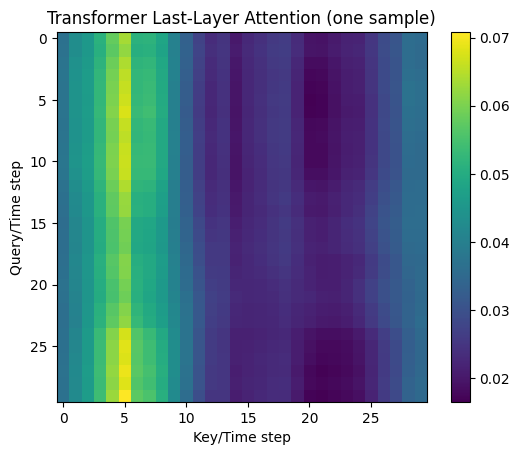

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 從 test_dl 取第一筆樣本
X_batch, _ = next(iter(test_dl))
sample_X = X_batch[0].unsqueeze(0).to(device)  # shape: (1, lookback, features)

# 執行模型並取得注意力
pred, attn_weights = transformer_model(sample_X, return_attn=True)

# head 平均並畫圖
attn_mean = attn_weights.mean(dim=0).cpu().detach().numpy()
plt.imshow(attn_mean, cmap='viridis')
plt.colorbar()
plt.title("Transformer Last-Layer Attention (one sample)")
plt.xlabel("Key/Time step")
plt.ylabel("Query/Time step")
plt.show()

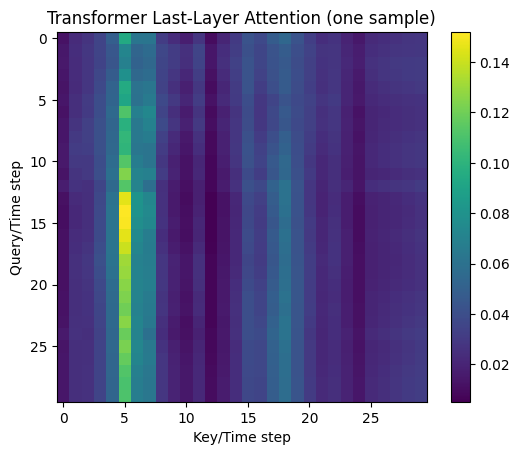

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 從 test_dl 取第一筆樣本
X_batch, _ = next(iter(val_dl))
sample_X = X_batch[0].unsqueeze(0).to(device)  # shape: (1, lookback, features)

# 執行模型並取得注意力
pred, attn_weights = transformer_model(sample_X, return_attn=True)

# head 平均並畫圖
attn_mean = attn_weights.mean(dim=0).cpu().detach().numpy()
plt.imshow(attn_mean, cmap='viridis')
plt.colorbar()
plt.title("Transformer Last-Layer Attention (one sample)")
plt.xlabel("Key/Time step")
plt.ylabel("Query/Time step")
plt.show()


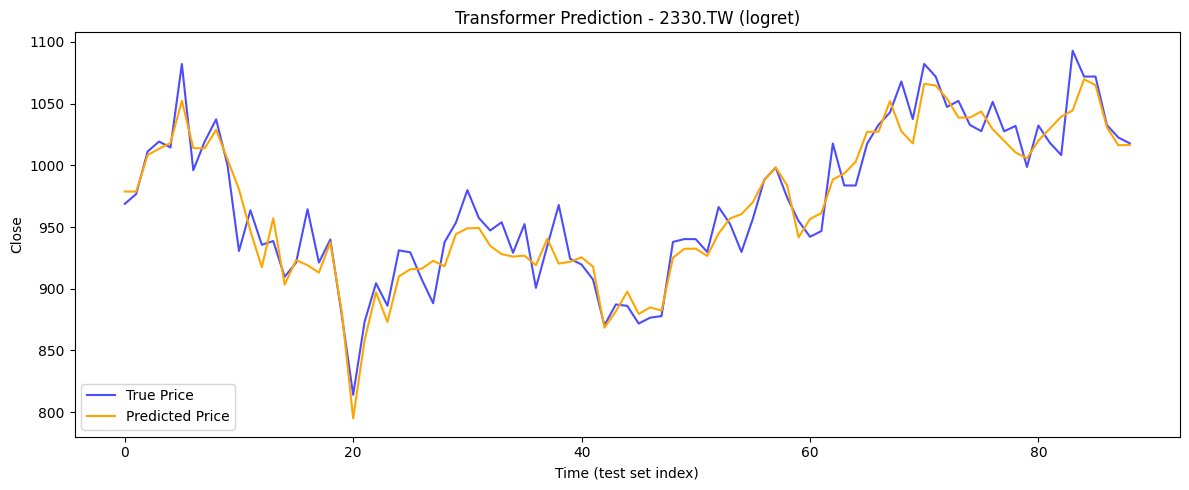

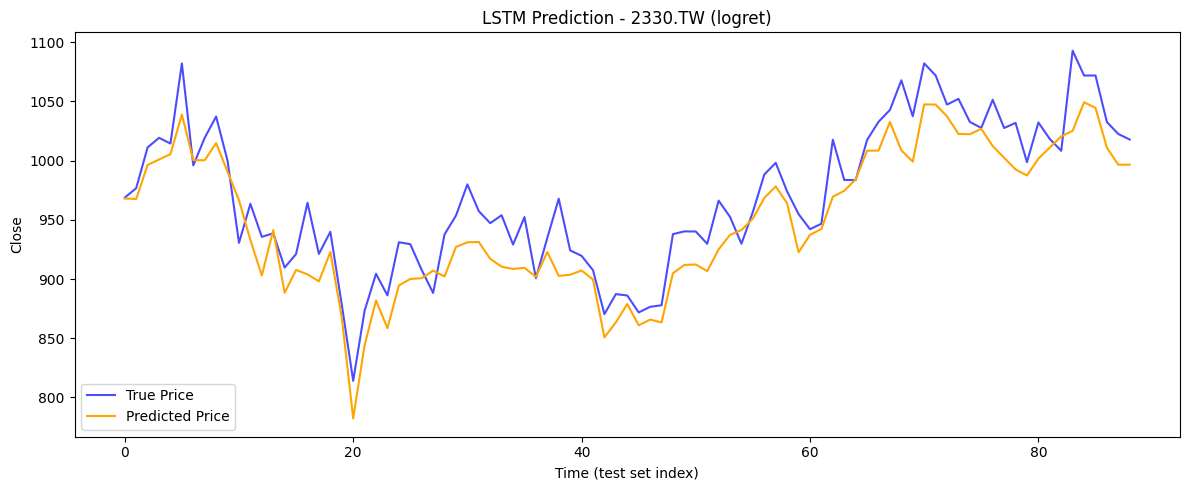

In [23]:
# 分別繪製 LSTM & Transformer 預測對照圖
def plot_predictions_separate(true_price_lstm, preds_price_lstm, true_price_tr, preds_price_tr):
    plt.figure(figsize=(12, 5))
    # LSTM 圖
    plt.plot(true_price_lstm, label='True Price', color='blue', alpha=0.7)
    plt.plot(preds_price_lstm, label='Predicted Price', color='orange', alpha=1)
    plt.title("Transformer Prediction - 2330.TW (logret)")
    plt.xlabel("Time (test set index)")
    plt.ylabel("Close")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    # Transformer 圖
    plt.plot(true_price_tr, label='True Price', color='blue', alpha=0.7)
    plt.plot(preds_price_tr, label='Predicted Price', color='orange', alpha=1)
    plt.title("LSTM Prediction - 2330.TW (logret)")
    plt.xlabel("Time (test set index)")
    plt.ylabel("Close")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 分別評估 LSTM 與 Transformer
metrics_lstm = evaluate_model(lstm_model, test_dl, scaler_y, test_close, use_last_step=True)
metrics_tr   = evaluate_model(transformer_model, test_dl, scaler_y, test_close, use_last_step=True)

true_price_lstm, preds_price_lstm = metrics_lstm[-2], metrics_lstm[-1]
true_price_tr, preds_price_tr     = metrics_tr[-2], metrics_tr[-1]

# 畫分開的圖
plot_predictions_separate(true_price_lstm, preds_price_lstm, true_price_tr, preds_price_tr)